# Customer Intelligence System using Classification, Ensemble Learning and Clustering

This notebook builds an end-to-end **Customer Intelligence System** using the provided Country Data resource.

The dataset is country-level, so I have treated each country as a **customer / market unit**. The aim is to segment these market units into meaningful groups and then build classification models that can predict those segments for new records.

Main techniques used:

- Data preprocessing and feature engineering
- Exploratory Data Analysis
- K-Means clustering
- DBSCAN clustering
- Random Forest classification
- XGBoost classification
- Hyperparameter tuning
- Customer segment profiling and business insights

## 1. Problem Statement

The objective of this project is to develop a Customer Intelligence System using classification, ensemble learning, and clustering.

The system first identifies meaningful customer/country segments using unsupervised learning. After that, those segment labels are used as the target variable for supervised classification models. This makes the project useful for understanding customers and also for predicting the segment of a new customer/market.

For this dataset, the final segment labels are:

- **High Priority**: countries/markets needing more attention based on weaker economic and social indicators
- **Medium Priority**: developing or moderate markets
- **Low Priority**: comparatively stable and developed markets

In [1]:
# Basic setup
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries imported successfully')

All libraries imported successfully


## 2. Load Dataset

The main dataset is `Country-data.csv`. The data dictionary is also loaded so that the meaning of columns is clear.

In [2]:
DATA_PATH = 'Country-data.csv'
DICTIONARY_PATH = 'data-dictionary.csv'

df = pd.read_csv(DATA_PATH)
data_dictionary = pd.read_csv(DICTIONARY_PATH, encoding='utf-8-sig')

print('Dataset loaded successfully')
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
display(df.head())

Dataset loaded successfully
Rows: 167
Columns: 10


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
print('Data Dictionary')
display(data_dictionary)

Data Dictionary


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


## 3. Data Understanding and Quality Check

Before modeling, I checked the basic structure, missing values, duplicate rows, and summary statistics.

In [4]:
print('Dataset information:')
display(df.info())

print('\nMissing values per column:')
display(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

print('\nSummary statistics:')
display(df.describe().T)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


None


Missing values per column:


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Duplicate rows: 0

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


### Data Quality Observation

The dataset is clean because there are no missing values and no duplicate rows. Still, scaling is required because the numerical features are on very different ranges. For example, income and GDP are much larger in scale than inflation or health percentage.

## 4. Feature Engineering

The original features are useful, but a few derived features can make the customer intelligence system more meaningful.

I created:

- `exports_value`: approximate export value per person
- `imports_value`: approximate import value per person
- `health_spend`: approximate health spending per person
- `economic_strength`: combined income and GDP strength
- `social_risk_score`: simple risk indicator based on child mortality, fertility, and life expectancy

In [5]:
work_df = df.copy()

work_df['exports_value'] = (work_df['exports'] * work_df['gdpp']) / 100
work_df['imports_value'] = (work_df['imports'] * work_df['gdpp']) / 100
work_df['health_spend'] = (work_df['health'] * work_df['gdpp']) / 100
work_df['economic_strength'] = work_df['income'] + work_df['gdpp']
work_df['social_risk_score'] = work_df['child_mort'] + (work_df['total_fer'] * 10) - work_df['life_expec']

base_features = [
    'child_mort', 'exports', 'health', 'imports', 'income',
    'inflation', 'life_expec', 'total_fer', 'gdpp'
]

engineered_features = [
    'exports_value', 'imports_value', 'health_spend',
    'economic_strength', 'social_risk_score'
]

feature_cols = base_features + engineered_features

print('New shape after feature engineering:', work_df.shape)
display(work_df[['country'] + engineered_features].head())

New shape after feature engineering: (167, 15)


,country,exports_value,imports_value,health_spend,economic_strength,social_risk_score
0,Afghanistan,55.30,248.297,41.9174,2163,92.2
1,Albania,1145.20,1987.740,267.8950,14020,-43.2
2,Algeria,1712.64,1400.440,185.9820,17360,-20.3
3,Angola,2199.19,1514.370,100.6050,9430,120.5
4,Antigua and Barbuda,5551.00,7185.800,735.6600,31300,-45.2


## 5. Exploratory Data Analysis

Here I explored the distribution of important indicators and relationships between development, economy, and health-related variables.

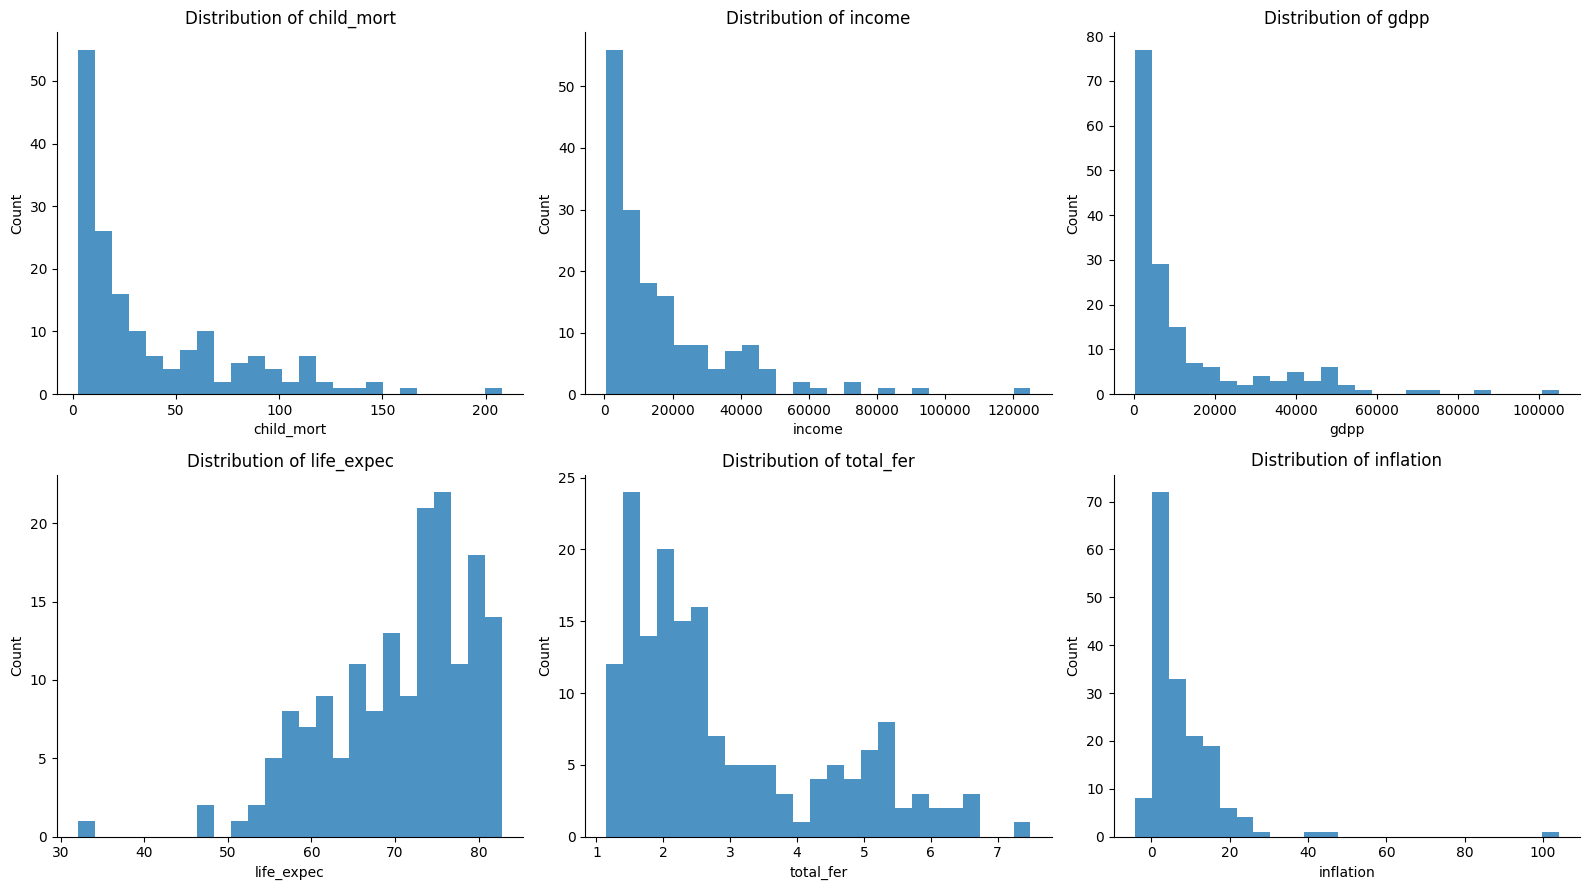

In [6]:
# Distribution plots for important indicators
important_cols = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'inflation']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, col in enumerate(important_cols):
    axes[i].hist(work_df[col], bins=25, alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

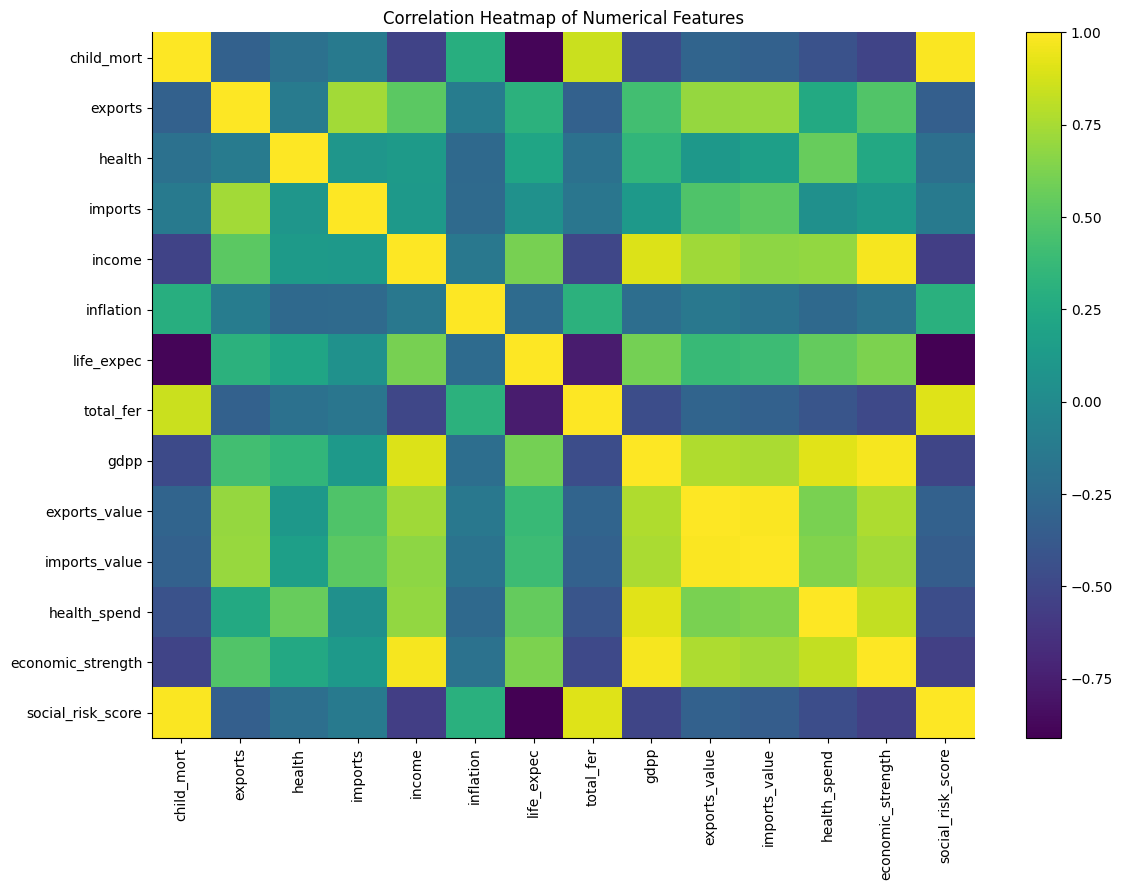

In [7]:
# Correlation heatmap using matplotlib
corr = work_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
ax.set_title('Correlation Heatmap of Numerical Features')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

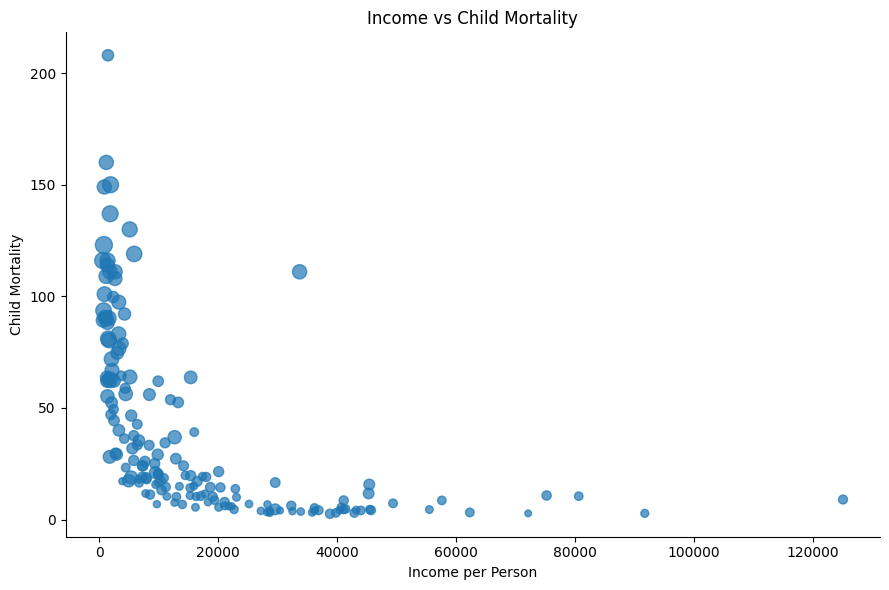

In [8]:
# Relationship between income, GDP and child mortality
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    work_df['income'],
    work_df['child_mort'],
    s=work_df['total_fer'] * 20,
    alpha=0.7
)
ax.set_xlabel('Income per Person')
ax.set_ylabel('Child Mortality')
ax.set_title('Income vs Child Mortality')
plt.tight_layout()
plt.show()

In [9]:
print('Top 10 countries with highest child mortality:')
display(work_df.sort_values('child_mort', ascending=False)[['country', 'child_mort', 'income', 'gdpp', 'life_expec']].head(10))

print('\nTop 10 countries with highest GDP per capita:')
display(work_df.sort_values('gdpp', ascending=False)[['country', 'gdpp', 'income', 'life_expec', 'child_mort']].head(10))

Top 10 countries with highest child mortality:


,country,child_mort,income,gdpp,life_expec
66,Haiti,208.0,1500,662,32.1
132,Sierra Leone,160.0,1220,399,55.0
32,Chad,150.0,1930,897,56.5
31,Central African Republic,149.0,888,446,47.5
97,Mali,137.0,1870,708,59.5
113,Nigeria,130.0,5150,2330,60.5
112,Niger,123.0,814,348,58.8
3,Angola,119.0,5900,3530,60.1
25,Burkina Faso,116.0,1430,575,57.9
37,"Congo, Dem. Rep.",116.0,609,334,57.5



Top 10 countries with highest GDP per capita:


,country,gdpp,income,life_expec,child_mort
91,Luxembourg,105000,91700,81.3,2.8
114,Norway,87800,62300,81.0,3.2
145,Switzerland,74600,55500,82.2,4.5
123,Qatar,70300,125000,79.5,9.0
44,Denmark,58000,44000,79.5,4.1
144,Sweden,52100,42900,81.5,3.0
7,Australia,51900,41400,82.0,4.8
110,Netherlands,50300,45500,80.7,4.5
73,Ireland,48700,45700,80.4,4.2
159,United States,48400,49400,78.7,7.3


### EDA Observation

Countries with high income and high GDP generally have lower child mortality and higher life expectancy. Countries with weaker economic indicators usually show higher child mortality and fertility rates. This confirms that clustering can create meaningful priority-based segments.

## 6. Preprocessing for Clustering

Clustering algorithms are distance-based, so feature scaling is important. Without scaling, large-value columns like income and GDP would dominate the clustering result.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(work_df[feature_cols])

scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
print('Scaled feature sample:')
display(scaled_df.head())

Scaled feature sample:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,exports_value,imports_value,health_spend,economic_strength,social_risk_score
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180,-0.411011,-0.432276,-0.565040,-0.765584,1.543483
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623,-0.350191,-0.313677,-0.439218,-0.440758,-0.656248
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376,-0.318526,-0.353720,-0.484826,-0.349258,-0.284211
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268,-0.291375,-0.345953,-0.532363,-0.566502,2.003249
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817,-0.104331,0.040735,-0.178771,0.032632,-0.688740


## 7. K-Means Clustering

I used the elbow method and silhouette score to understand a good number of clusters. For business interpretation, 3 clusters are selected because they clearly map into High, Medium and Low Priority segments.

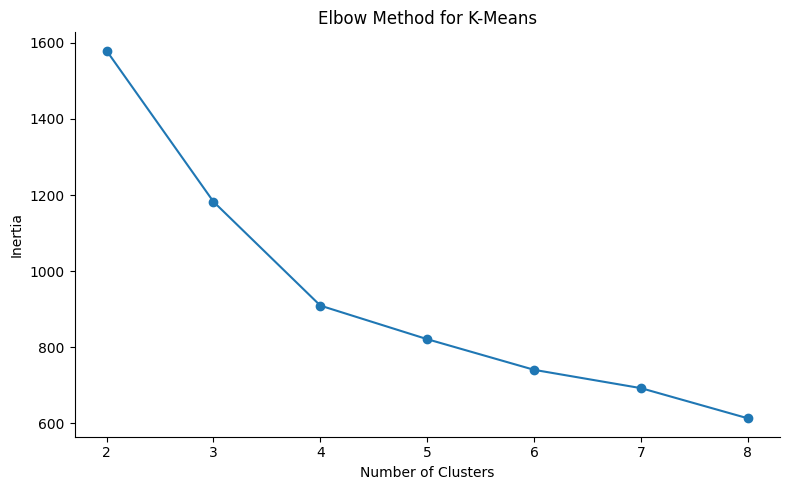

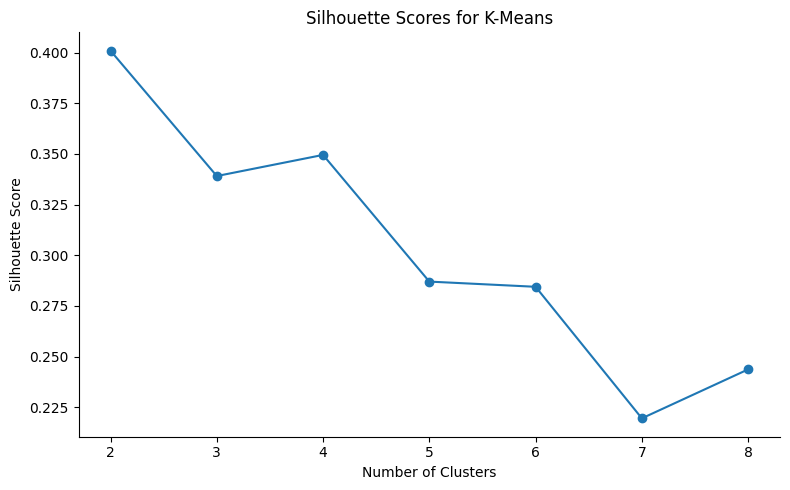

,k,inertia,silhouette_score
0,2,1579.571144,0.400955
1,3,1182.413352,0.339104
2,4,909.176683,0.349534
3,5,820.863165,0.287014
4,6,740.261450,0.284452
5,7,692.101131,0.219531
6,8,612.713964,0.243686


In [11]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), inertias, marker='o')
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for K-Means')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), silhouette_scores, marker='o')
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Scores for K-Means')
plt.tight_layout()
plt.show()

silhouette_table = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias,
    'silhouette_score': silhouette_scores
})
display(silhouette_table)

In [12]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
work_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('K-Means cluster counts:')
display(work_df['kmeans_cluster'].value_counts().sort_index())

K-Means cluster counts:


kmeans_cluster
0    93
1    29
2    45
Name: count, dtype: int64

## 8. Segment Label Creation

K-Means gives cluster numbers like 0, 1 and 2. These numbers do not have business meaning by themselves, so I converted them into readable customer intelligence labels.

The segment naming is based on a priority score:

- Higher child mortality, fertility, inflation and social risk increase priority
- Higher income, GDP and life expectancy reduce priority

In [13]:
cluster_profile = work_df.groupby('kmeans_cluster')[feature_cols].mean().round(2)
print('Cluster profile:')
display(cluster_profile)

priority_features = [
    'child_mort', 'total_fer', 'inflation', 'social_risk_score',
    'income', 'gdpp', 'life_expec'
]

priority_profile = work_df.groupby('kmeans_cluster')[priority_features].mean()
priority_scaled = pd.DataFrame(
    StandardScaler().fit_transform(priority_profile),
    index=priority_profile.index,
    columns=priority_profile.columns
)

priority_score = (
    priority_scaled['child_mort']
    + priority_scaled['total_fer']
    + priority_scaled['inflation']
    + priority_scaled['social_risk_score']
    - priority_scaled['income']
    - priority_scaled['gdpp']
    - priority_scaled['life_expec']
)

ordered_clusters = priority_score.sort_values(ascending=False).index.tolist()
segment_map = {
    ordered_clusters[0]: 'High Priority',
    ordered_clusters[1]: 'Medium Priority',
    ordered_clusters[2]: 'Low Priority'
}

work_df['Customer_Segment'] = work_df['kmeans_cluster'].map(segment_map)

print('Cluster to segment mapping:')
print(segment_map)

print('\nCustomer segment counts:')
display(work_df['Customer_Segment'].value_counts())

Cluster profile:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,exports_value,imports_value,health_spend,economic_strength,social_risk_score
kmeans_cluster,,,,,,,,,,,,,,
0,21.15,40.99,6.40,47.44,13657.74,7.28,73.03,2.30,7687.23,3420.53,3535.18,522.76,21344.97,-28.92
1,4.98,60.91,8.95,52.24,49437.93,2.88,80.48,1.75,47262.07,30486.79,25435.36,4253.88,96700.00,-57.96
2,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71,822.61,752.40,99.90,5306.56,86.70


Cluster to segment mapping:
{2: 'High Priority', 0: 'Medium Priority', 1: 'Low Priority'}

Customer segment counts:


Customer_Segment
Medium Priority    93
High Priority      45
Low Priority       29
Name: count, dtype: int64

In [14]:
segment_profile = work_df.groupby('Customer_Segment')[feature_cols].mean().round(2)
print('Customer segment profile:')
display(segment_profile)

print('Example countries from each segment:')
for segment in ['High Priority', 'Medium Priority', 'Low Priority']:
    print(f'\n{segment}:')
    display(work_df[work_df['Customer_Segment'] == segment][['country', 'income', 'gdpp', 'child_mort', 'life_expec']].head(8))

Customer segment profile:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,exports_value,imports_value,health_spend,economic_strength,social_risk_score
Customer_Segment,,,,,,,,,,,,,,
High Priority,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71,822.61,752.40,99.90,5306.56,86.70
Low Priority,4.98,60.91,8.95,52.24,49437.93,2.88,80.48,1.75,47262.07,30486.79,25435.36,4253.88,96700.00,-57.96
Medium Priority,21.15,40.99,6.40,47.44,13657.74,7.28,73.03,2.30,7687.23,3420.53,3535.18,522.76,21344.97,-28.92


Example countries from each segment:

High Priority:


,country,income,gdpp,child_mort,life_expec
0,Afghanistan,1610,553,90.2,56.2
3,Angola,5900,3530,119.0,60.1
17,Benin,1820,758,111.0,61.8
25,Burkina Faso,1430,575,116.0,57.9
26,Burundi,764,231,93.6,57.7
28,Cameroon,2660,1310,108.0,57.3
31,Central African Republic,888,446,149.0,47.5
32,Chad,1930,897,150.0,56.5



Medium Priority:


,country,income,gdpp,child_mort,life_expec
1,Albania,9930,4090,16.6,76.3
2,Algeria,12900,4460,27.3,76.5
4,Antigua and Barbuda,19100,12200,10.3,76.8
5,Argentina,18700,10300,14.5,75.8
6,Armenia,6700,3220,18.1,73.3
9,Azerbaijan,16000,5840,39.2,69.1
10,Bahamas,22900,28000,13.8,73.8
11,Bahrain,41100,20700,8.6,76.0



Low Priority:


,country,income,gdpp,child_mort,life_expec
7,Australia,41400,51900,4.8,82.0
8,Austria,43200,46900,4.3,80.5
15,Belgium,41100,44400,4.5,80.0
23,Brunei,80600,35300,10.5,77.1
29,Canada,40700,47400,5.6,81.3
42,Cyprus,33900,30800,3.6,79.9
44,Denmark,44000,58000,4.1,79.5
53,Finland,39800,46200,3.0,80.0


## 9. PCA Visualization of K-Means Segments

PCA is used only for visualization. It reduces the scaled features into two components so that the clusters can be shown on a 2D plot.

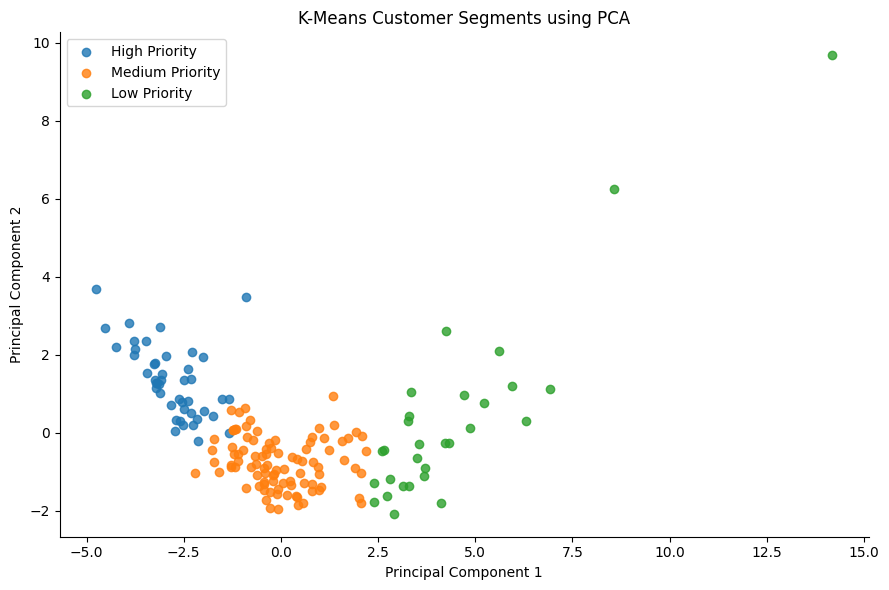

Explained variance ratio: [0.51824793 0.16344531]


In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

work_df['PC1'] = X_pca[:, 0]
work_df['PC2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))
for segment in work_df['Customer_Segment'].unique():
    temp = work_df[work_df['Customer_Segment'] == segment]
    ax.scatter(temp['PC1'], temp['PC2'], label=segment, alpha=0.8)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('K-Means Customer Segments using PCA')
ax.legend()
plt.tight_layout()
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_)

## 10. DBSCAN Clustering

DBSCAN is also used as required. Unlike K-Means, DBSCAN detects dense regions and can mark unusual countries as noise/outliers.

For better visualization and more stable density grouping, DBSCAN is applied on the 2D PCA representation.

DBSCAN cluster counts:


dbscan_cluster
-1     17
 0    150
Name: count, dtype: int64

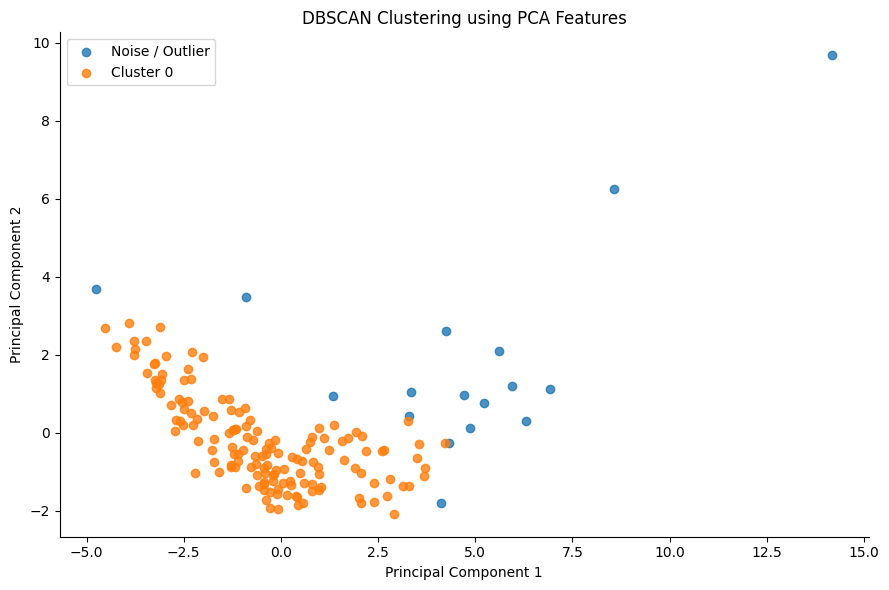

Countries marked as DBSCAN outliers/noise:


,country,income,gdpp,child_mort,life_expec
8,Austria,43200,46900,4.3,80.5
15,Belgium,41100,44400,4.5,80.0
44,Denmark,44000,58000,4.1,79.5
49,Equatorial Guinea,33700,17100,111.0,60.9
66,Haiti,1500,662,208.0,32.1
73,Ireland,45700,48700,4.2,80.4
82,Kuwait,75200,38500,10.8,78.2
91,Luxembourg,91700,105000,2.8,81.3
98,Malta,28300,21100,6.8,80.3
110,Netherlands,45500,50300,4.5,80.7


In [16]:
dbscan = DBSCAN(eps=0.7, min_samples=4)
work_df['dbscan_cluster'] = dbscan.fit_predict(X_pca)

print('DBSCAN cluster counts:')
display(work_df['dbscan_cluster'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(9, 6))
for cluster in sorted(work_df['dbscan_cluster'].unique()):
    temp = work_df[work_df['dbscan_cluster'] == cluster]
    label = 'Noise / Outlier' if cluster == -1 else f'Cluster {cluster}'
    ax.scatter(temp['PC1'], temp['PC2'], label=label, alpha=0.8)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('DBSCAN Clustering using PCA Features')
ax.legend()
plt.tight_layout()
plt.show()

print('Countries marked as DBSCAN outliers/noise:')
display(work_df[work_df['dbscan_cluster'] == -1][['country', 'income', 'gdpp', 'child_mort', 'life_expec']].head(20))

### DBSCAN Observation

DBSCAN is useful here because it can identify countries that behave differently from dense groups. These outlier countries can be reviewed separately because they may represent unusual economic or social patterns.

## 11. Classification Dataset Preparation

Now the cluster-based segment label becomes the classification target. The model will learn how to predict whether a country/customer belongs to High Priority, Medium Priority, or Low Priority segment.

In [17]:
X = work_df[feature_cols].copy()

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(work_df['Customer_Segment'])

print('Target classes:')
for i, label in enumerate(target_encoder.classes_):
    print(i, '->', label)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Target classes:
0 -> High Priority
1 -> Low Priority
2 -> Medium Priority
Training shape: (125, 14)
Testing shape: (42, 14)


## 12. Baseline and Ensemble Classification Models

I trained one baseline model and two ensemble models:

- Logistic Regression: baseline classifier
- Random Forest: bagging-based ensemble model
- XGBoost: boosting-based ensemble model

In [18]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, preds, average='weighted', zero_division=0),
        'F1 Score': f1_score(y_test, preds, average='weighted', zero_division=0)
    }

models = {}

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)
models['Logistic Regression'] = log_reg

rf_clf = RandomForestClassifier(
    n_estimators=250,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
rf_clf.fit(X_train, y_train)
models['Random Forest'] = rf_clf

xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=1
)
xgb_clf.fit(X_train, y_train)
models['XGBoost'] = xgb_clf

model_results = pd.DataFrame([
    evaluate_model(name, model, X_test, y_test)
    for name, model in models.items()
]).sort_values('F1 Score', ascending=False)

display(model_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.976190,0.979167,0.976190,0.976731
1,Random Forest,0.952381,0.962963,0.952381,0.954322
2,XGBoost,0.952381,0.962963,0.952381,0.954322


## 13. Hyperparameter Tuning

To improve predictive performance, I tuned Random Forest and XGBoost using `RandomizedSearchCV`. Since the dataset is small, I kept the search space practical so the notebook can run smoothly.

In [19]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5, 8],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_distributions=rf_param_grid,
    n_iter=6,
    scoring='f1_weighted',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1
)

rf_search.fit(X_train, y_train)

print('Best Random Forest CV F1:', round(rf_search.best_score_, 4))
print('Best Random Forest params:')
print(rf_search.best_params_)

Best Random Forest CV F1: 0.9604
Best Random Forest params:
{'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': None}


In [20]:
xgb_param_grid = {
    'n_estimators': [80, 120, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    param_distributions=xgb_param_grid,
    n_iter=6,
    scoring='f1_weighted',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1
)

xgb_search.fit(X_train, y_train)

print('Best XGBoost CV F1:', round(xgb_search.best_score_, 4))
print('Best XGBoost params:')
print(xgb_search.best_params_)

Best XGBoost CV F1: 0.9518
Best XGBoost params:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


In [21]:
tuned_models = {
    'Tuned Random Forest': rf_search.best_estimator_,
    'Tuned XGBoost': xgb_search.best_estimator_
}

final_results = pd.DataFrame([
    evaluate_model(name, model, X_test, y_test)
    for name, model in tuned_models.items()
]).sort_values('F1 Score', ascending=False)

display(final_results)

best_model_name = final_results.iloc[0]['Model']
best_model = tuned_models[best_model_name]

print('Best final model:', best_model_name)

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Random Forest,0.952381,0.962963,0.952381,0.954322
1,Tuned XGBoost,0.952381,0.962963,0.952381,0.954322


Best final model: Tuned Random Forest


## 14. Final Model Evaluation

The final model is evaluated using a classification report and confusion matrix.

                 precision    recall  f1-score   support

  High Priority       1.00      1.00      1.00        11
   Low Priority       0.78      1.00      0.88         7
Medium Priority       1.00      0.92      0.96        24

       accuracy                           0.95        42
      macro avg       0.93      0.97      0.94        42
   weighted avg       0.96      0.95      0.95        42



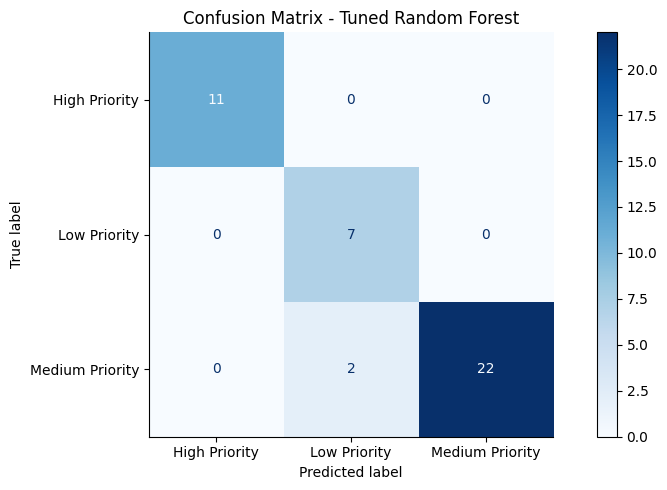

In [22]:
y_pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

## 15. Feature Importance

Feature importance helps understand which indicators are most useful for predicting the segment.

Top important features:


,importance
social_risk_score,0.177357
child_mort,0.141387
economic_strength,0.102569
life_expec,0.102415
gdpp,0.099623
income,0.081450
health_spend,0.079232
total_fer,0.075707
imports_value,0.063414
exports_value,0.057986


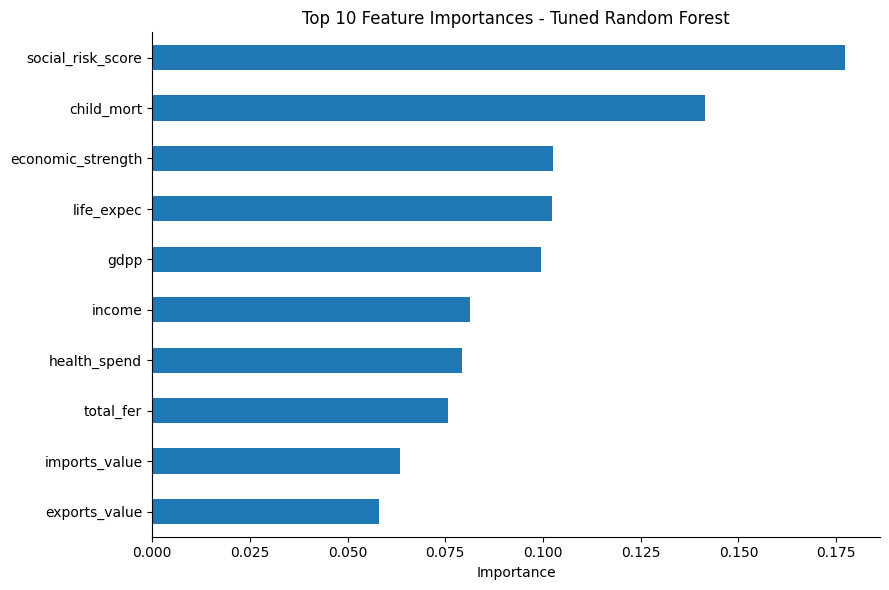

In [23]:
importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

print('Top important features:')
display(importance.head(10).to_frame('importance'))

fig, ax = plt.subplots(figsize=(9, 6))
importance.head(10).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Importance')
ax.set_title(f'Top 10 Feature Importances - {best_model_name}')
plt.tight_layout()
plt.show()

## 16. Actionable Customer Segmentation Insights

The main value of this system is not only prediction but also segment understanding. Below are practical recommendations for each segment.

In [24]:
summary = work_df.groupby('Customer_Segment').agg(
    countries=('country', 'count'),
    avg_child_mort=('child_mort', 'mean'),
    avg_income=('income', 'mean'),
    avg_gdpp=('gdpp', 'mean'),
    avg_life_expec=('life_expec', 'mean'),
    avg_total_fer=('total_fer', 'mean')
).round(2)

display(summary)

,countries,avg_child_mort,avg_income,avg_gdpp,avg_life_expec,avg_total_fer
Customer_Segment,,,,,,
High Priority,45,95.11,3539.84,1766.71,59.06,5.07
Low Priority,29,4.98,49437.93,47262.07,80.48,1.75
Medium Priority,93,21.15,13657.74,7687.23,73.03,2.30


### Business Interpretation

- **High Priority Segment:** These countries have weaker economic and social indicators. They need urgent attention, support programs, funding, health initiatives and development-focused planning.

- **Medium Priority Segment:** These countries are in the middle stage. They may not need emergency intervention, but they can benefit from targeted investment and policy support.

- **Low Priority Segment:** These countries are comparatively stable with stronger income, GDP and life expectancy. For these markets, the focus can be on premium services, partnerships and long-term growth.

## 17. Save Final Segmentation Output

The final output file contains each country with its K-Means segment and DBSCAN cluster label.

In [25]:
output_cols = ['country'] + feature_cols + ['Customer_Segment', 'kmeans_cluster', 'dbscan_cluster']
output_file = 'customer_intelligence_segments.csv'

work_df[output_cols].to_csv(output_file, index=False)
print(f'Saved final segmented data to: {output_file}')
display(work_df[output_cols].head())

Saved final segmented data to: customer_intelligence_segments.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,exports_value,imports_value,health_spend,economic_strength,social_risk_score,Customer_Segment,kmeans_cluster,dbscan_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,55.30,248.297,41.9174,2163,92.2,High Priority,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1145.20,1987.740,267.8950,14020,-43.2,Medium Priority,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1712.64,1400.440,185.9820,17360,-20.3,Medium Priority,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2199.19,1514.370,100.6050,9430,120.5,High Priority,2,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,5551.00,7185.800,735.6600,31300,-45.2,Medium Priority,0,0


## 18. Final Conclusion

This project developed an end-to-end Customer Intelligence System using clustering, classification and ensemble learning.

K-Means was used to create meaningful customer/country segments, and DBSCAN helped detect dense groups and possible outliers. After creating the segment labels, supervised classification models were trained to predict those customer segments. Random Forest and XGBoost were included as ensemble models, and hyperparameter tuning was used to improve model performance.

The final system provides both predictive output and actionable business insights, making it useful for customer prioritization, market strategy and resource planning.